[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RlNZLER/Reinforcement-Learning/blob/main/minor_projects/chapter-2-bandit/gradient_bandit_demo.ipynb)


# Gradient Bandit Algorithm — Chapter 2 Demo

This notebook implements the **Gradient Bandit** algorithm for the k-armed bandit and compares it to
a baseline that uses **softmax over sample-average Q-values**.

**Key idea:** Learn *preferences* \(H(a)\) and form a stochastic policy via softmax:
\[
\pi(a) = \frac{e^{H(a)}}{\sum_b e^{H(b)}}.
\]

**Update rule (with baseline \(b_t\)):**
\[
H_{t+1}(a) = H_t(a) + \alpha \,(R_t - b_t) \,\big(\mathbf{1}\{a=A_t\} - \pi_t(a)\big).
\]

The baseline \(b_t\) is typically the running average reward and helps **reduce variance**.



## Experiment Setup

- **Arms:** 10
- **Steps per run:** 800
- **Independent runs (averaged):** 200
- **Reward model:** True action values \(q^*(a)\sim \mathcal{N}(0,1)\); rewards \(R\sim \mathcal{N}(q^*(A), 1)\).
- **Comparisons:**
  - Gradient Bandit with baseline, \(\alpha\in\{0.1, 0.4\}\)
  - Gradient Bandit without baseline (variance is higher)
  - Softmax over Q with **sample-average** updates (not a gradient method, included as a baseline)


In [1]:

import numpy as np
import matplotlib.pyplot as plt

N_ACTIONS = 10
N_STEPS = 2000
N_RUNS = 1000
ALPHAS = [0.1, 0.4]


In [2]:

def softmax(x):
    z = x - np.max(x)
    e = np.exp(z)
    return e / np.sum(e)

def simulate_gradient_bandit(alpha=0.1, use_baseline=True, n_actions=N_ACTIONS, n_steps=N_STEPS, n_runs=N_RUNS, seed=0):
    rng = np.random.default_rng(seed)
    avg_rewards = np.zeros(n_steps)
    pct_optimal = np.zeros(n_steps)

    for run in range(n_runs):
        q_true = rng.normal(0.0, 1.0, size=n_actions)
        optimal = int(np.argmax(q_true))

        H = np.zeros(n_actions)
        avg_r = 0.0

        for t in range(1, n_steps + 1):
            pi = softmax(H)
            a = rng.choice(n_actions, p=pi)
            r = rng.normal(q_true[a], 1.0)

            b = avg_r if use_baseline else 0.0
            one_hot = np.zeros(n_actions); one_hot[a] = 1.0
            H += alpha * (r - b) * (one_hot - pi)

            avg_r += (r - avg_r) / t

            avg_rewards[t-1] += r
            if a == optimal:
                pct_optimal[t-1] += 1

    avg_rewards /= n_runs
    pct_optimal = pct_optimal / n_runs * 100.0
    return avg_rewards, pct_optimal

def simulate_softmax_q(alpha=0.1, n_actions=N_ACTIONS, n_steps=N_STEPS, n_runs=N_RUNS, seed=123):
    rng = np.random.default_rng(seed)
    avg_rewards = np.zeros(n_steps)
    pct_optimal = np.zeros(n_steps)

    for run in range(n_runs):
        q_true = rng.normal(0.0, 1.0, size=n_actions)
        optimal = int(np.argmax(q_true))

        Q = np.zeros(n_actions)
        N = np.zeros(n_actions, dtype=int)

        for t in range(1, n_steps + 1):
            pi = softmax(Q)
            a = rng.choice(n_actions, p=pi)
            r = rng.normal(q_true[a], 1.0)

            N[a] += 1
            Q[a] += (r - Q[a]) / N[a]

            avg_rewards[t-1] += r
            if a == optimal:
                pct_optimal[t-1] += 1

    avg_rewards /= n_runs
    pct_optimal = pct_optimal / n_runs * 100.0
    return avg_rewards, pct_optimal


In [3]:

results_grad_baseline = {a: simulate_gradient_bandit(alpha=a, use_baseline=True) for a in ALPHAS}
results_grad_nobase = {a: simulate_gradient_bandit(alpha=a, use_baseline=False) for a in ALPHAS}
results_softmax_q = simulate_softmax_q()


### Plot: Average Reward

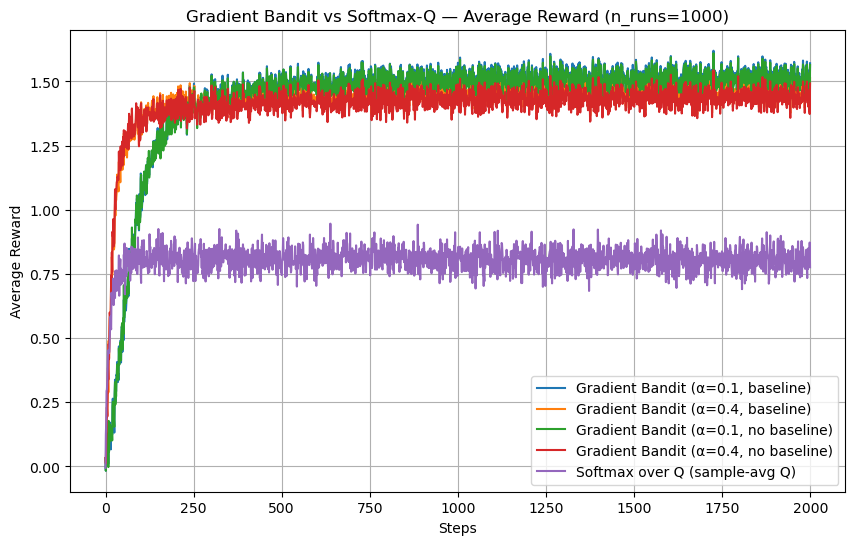

In [4]:

plt.figure(figsize=(10, 6))
for a in ALPHAS:
    plt.plot(results_grad_baseline[a][0], label=f"Gradient Bandit (α={a}, baseline)")
for a in ALPHAS:
    plt.plot(results_grad_nobase[a][0], label=f"Gradient Bandit (α={a}, no baseline)")
plt.plot(results_softmax_q[0], label="Softmax over Q (sample-avg Q)")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title(f"Gradient Bandit vs Softmax-Q — Average Reward (n_runs={N_RUNS})")
plt.grid(True)
plt.legend()
plt.show()


### Plot: % Optimal Action

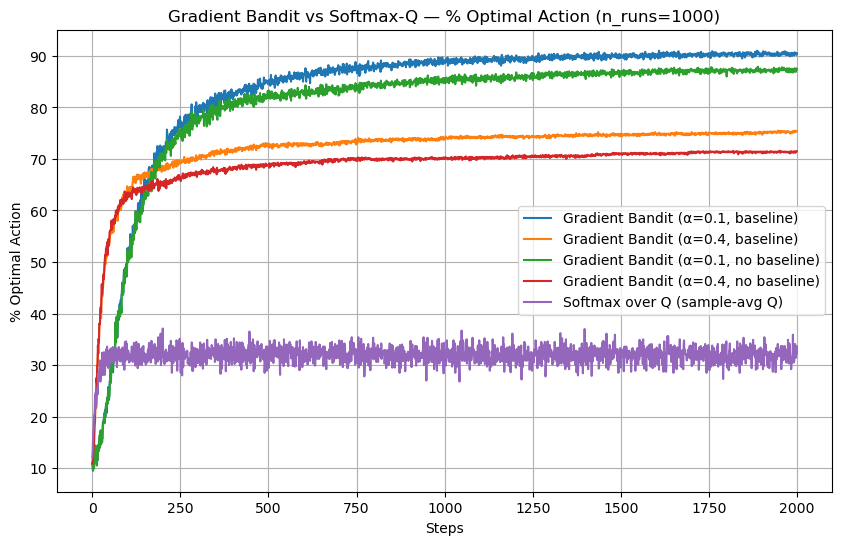

In [5]:

plt.figure(figsize=(10, 6))
for a in ALPHAS:
    plt.plot(results_grad_baseline[a][1], label=f"Gradient Bandit (α={a}, baseline)")
for a in ALPHAS:
    plt.plot(results_grad_nobase[a][1], label=f"Gradient Bandit (α={a}, no baseline)")
plt.plot(results_softmax_q[1], label="Softmax over Q (sample-avg Q)")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title(f"Gradient Bandit vs Softmax-Q — % Optimal Action (n_runs={N_RUNS})")
plt.grid(True)
plt.legend()
plt.show()



## Notes
- The **baseline** (running average reward) reduces variance and stabilizes learning.
- Larger **α** can speed up learning but may cause instability; compare α=0.1 and α=0.4.
- This algorithm learns a **stochastic policy** directly — it's the bandit-sized ancestor of modern **policy gradients** (e.g., REINFORCE, Actor-Critic).
